### 🎯 Goal:  Predict a fair salary for a new employee (say at Level=6.5), using SVR


In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [73]:
# Load the dataset
employee_df = pd.read_csv(r"C:\Users\vamsi\Downloads\emp_sal.csv")
employee_df.head()


,Position,Level,Salary
0,Jr Software Engineer,1,45000
1,Sr Software Engineer,2,50000
2,Team Lead,3,60000
3,Manager,4,80000
4,Sr manager,5,110000


In [83]:
# Extract features and target

X = employee_df.iloc[:, 1:2].values # Position levels
y = employee_df.iloc[:, 2].values   # corresponding salaries

In [102]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Train the model
line_reg = LinearRegression()
line_reg.fit(X, y)  #  Now the model has learned the relationship between level and salary


LinearRegression()

### *********Visualize Linear Regression**********

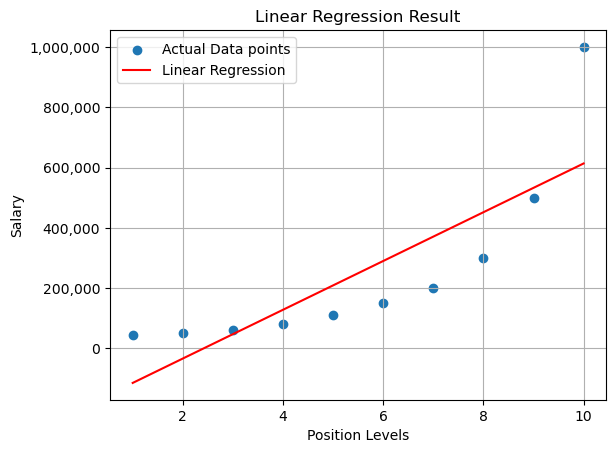

In [146]:
plt.scatter(X, y, label='Actual Data points')

# plot linear regression prediction
plt.plot(X, line_reg.predict(X), color='red', label='Linear Regression') 

# X is your input values (position levels like 1, 2, 3... 10).
# lin_reg.predict(X) means the predicted salaries for each level using the linear model.

# Labels and Titles
plt.title('Linear Regression Result')
plt.xlabel('Position Levels')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)

# 🔧 Set Y-axis to plain format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

In [170]:
salary_to_predict = [[6.5]]
predicted_salary = line_reg.predict(salary_to_predict)
print("Linear Regression predicted salary Rs.", predicted_salary[0])

Linear Regression predicted salary Rs. 330378.7878787879


But, Look at the original salary data :
* Level 6: 150,000  
* Level 7: 200,000

😬 Problem?
* Thats because Linear Regression **fits a straight line**, which is not flexible enough to match real-world patterns.

### POLYNOMIAL REGRESSION

Now let's train a ****Polynomial regression***** to capture the non-linear data

In [529]:
from sklearn.preprocessing import PolynomialFeatures

#     Degree 2 polynomial (quadratic curve)
poly_reg = PolynomialFeatures(degree=5)
X_poly = poly_reg.fit_transform(X) # new columns are created

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

LinearRegression()

### *********Visualize Polynomial Regression**********

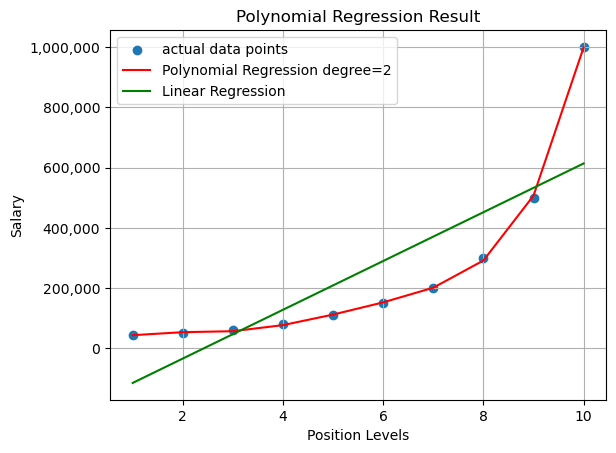

In [532]:
plt.scatter(X, y, label='actual data points')
plt.plot(X, poly_model.predict(X_poly), color='red', label='Polynomial Regression degree=2')

# Labels and Titles
plt.title('Polynomial Regression Result')
plt.xlabel('Position Levels')
plt.ylabel('Salary')
plt.plot(X, line_reg.predict(X), color='green', label='Linear Regression')
plt.legend()
plt.grid(True)


# 🔧 Set Y-axis to plain format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

In [534]:
salary_to_predict= [[6.5]]
salary_predicted = poly_model.predict(poly_reg.transform(salary_to_predict))
print(f"Salary Predicted for Polynomial Regresion:  Rs. {salary_predicted[0]:.2f}   ")

Salary Predicted for Polynomial Regresion:  Rs. 174878.08   


In [536]:
from sklearn.metrics import r2_score

y_pred_poly = poly_model.predict(X_poly)
r2_score(y, y_pred_poly)

0.9997969027099755

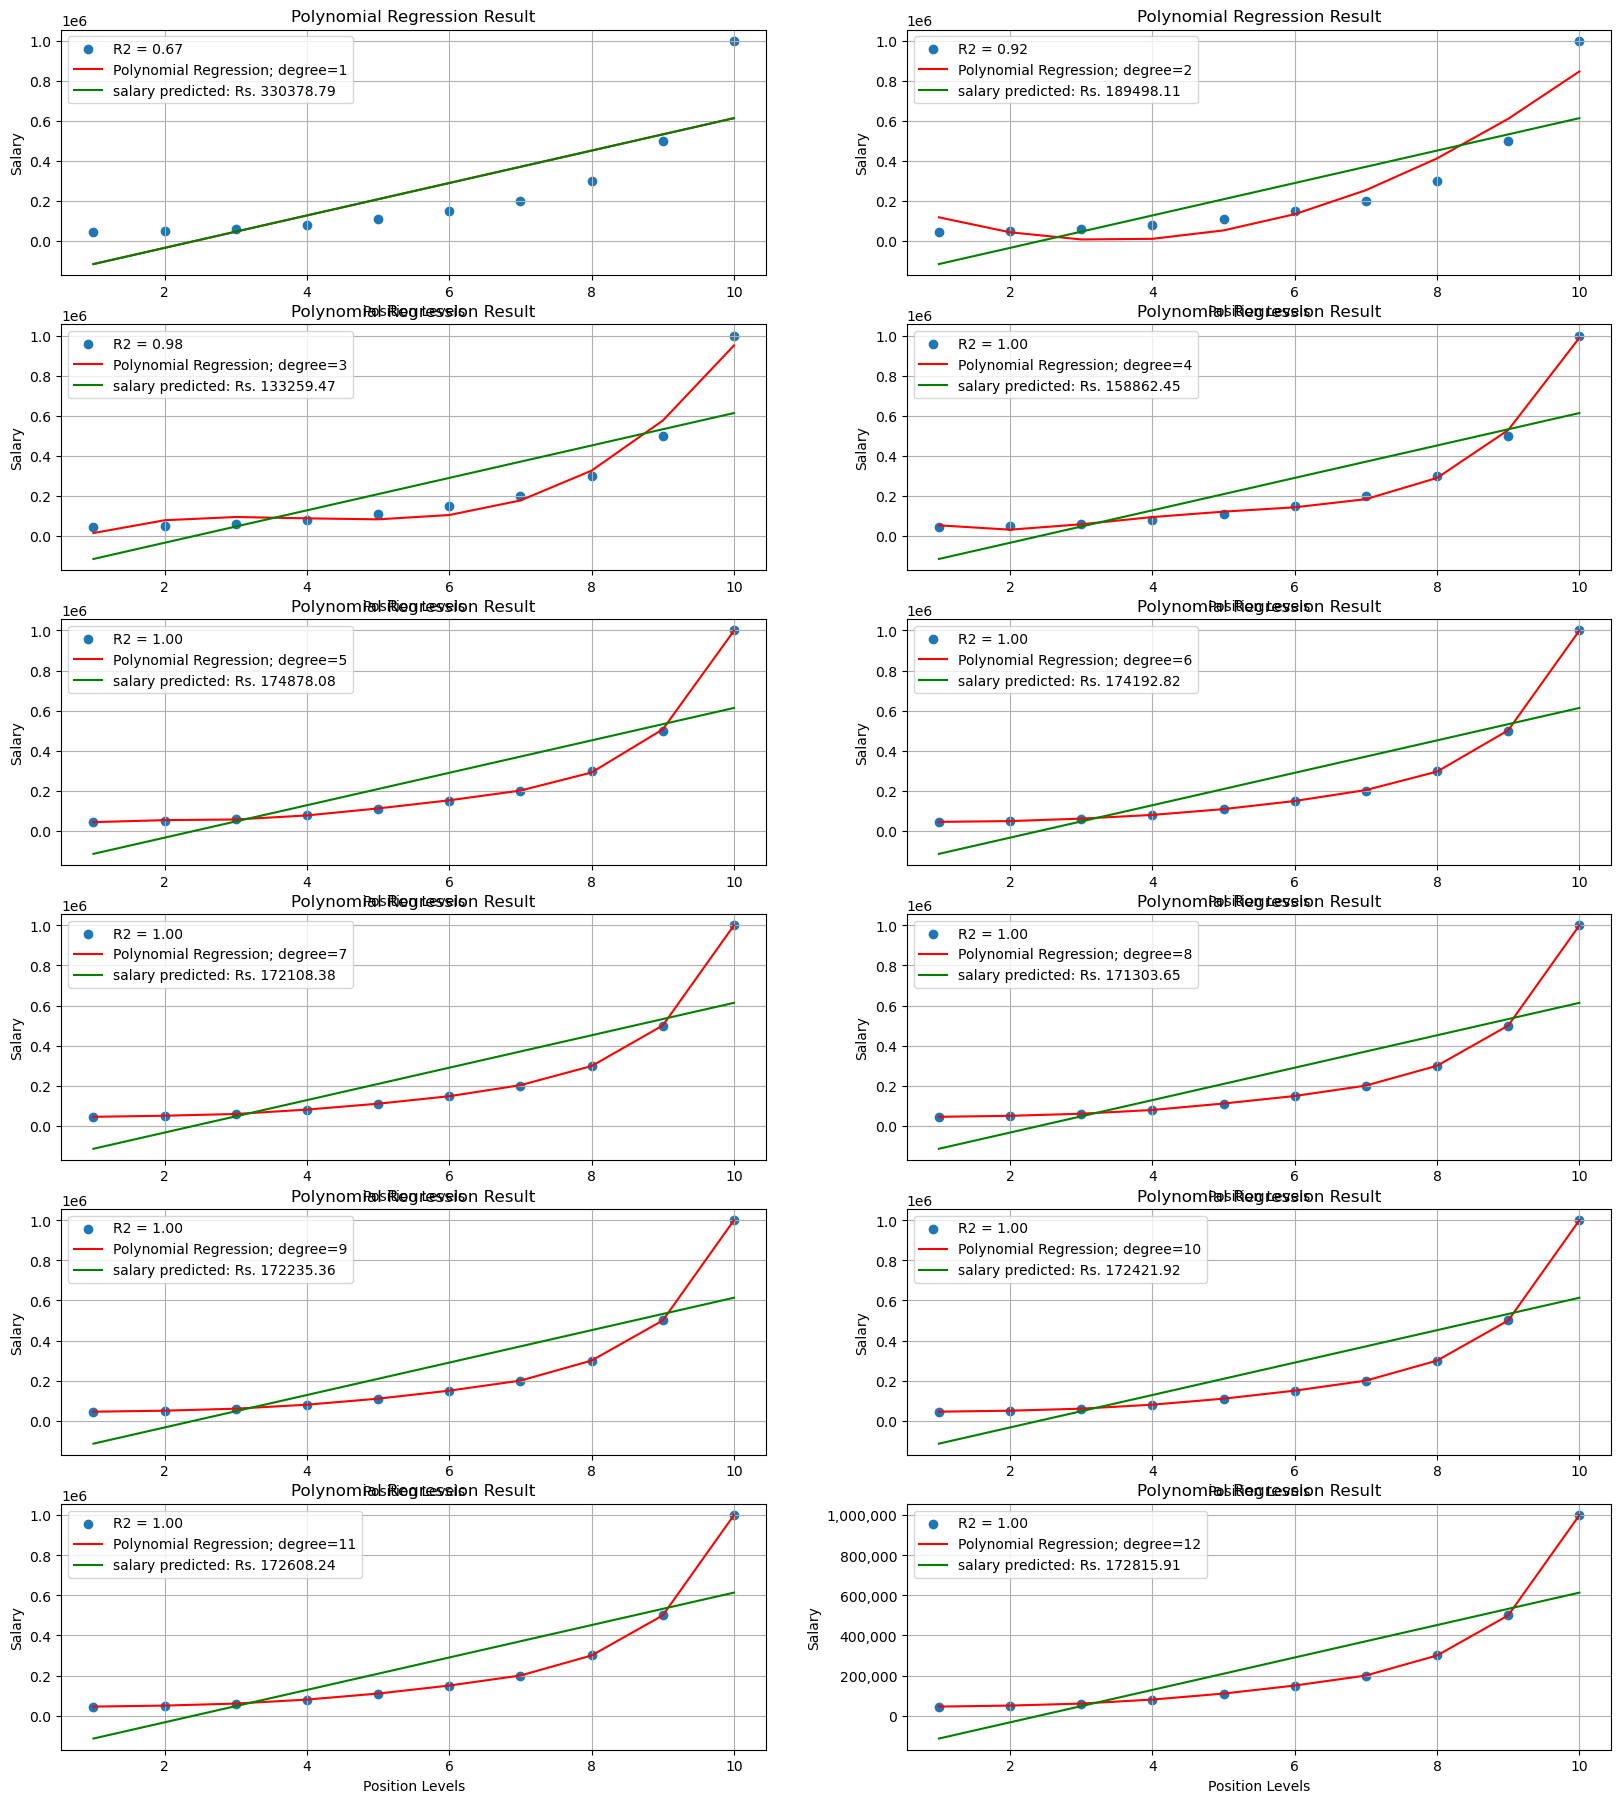

In [338]:
from sklearn.preprocessing import PolynomialFeatures

plt.figure(figsize=(20,30))

for i in range(1,13):
    poly_reg = PolynomialFeatures(degree=i)
    X_poly = poly_reg.fit_transform(X) # new columns are created

    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)

    salary_to_predict= [[6.5]]
    salary_predicted = poly_model.predict(poly_reg.transform(salary_to_predict))

    y_pred_poly = poly_model.predict(X_poly)
    r2 = r2_score(y, y_pred_poly)


    plt.subplot(8,2, i) # 8 rows, 2 col, subplot number = degree i
    plt.scatter(X, y, label=f'R2 = {r2:.2f}')
    plt.plot(X, poly_model.predict(X_poly), color='red', label=f'Polynomial Regression; degree={i}')

  
    # Labels and Titles
    plt.title('Polynomial Regression Result')
    plt.xlabel('Position Levels')
    plt.ylabel('Salary')
    plt.plot(X, line_reg.predict(X), color='green', label=f'salary predicted: Rs. {salary_predicted[0]:.2f}')
    plt.legend()
    plt.grid(True)


# 🔧 Set Y-axis to plain format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

🔍 Insight:
* **Degree 5 and 6 give nearly identical results**
* Degree 7 is dropping its value slightly might be overfitting
* Generally Degree < 1 = Underfitting AND Degree>10 can be overfitting

### SUPPORT VECTOR REGRESSION (SVR)

In [443]:
# Lets standardize both X, y

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1,1)) # -1 means i dont care how many rows -> finally becomes 2D (10,1)

In [445]:
from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(X_scaled, y_scaled.ravel()) # fit expects 1D array so ravel it

SVR()

In [455]:
level_scaled = sc_X.transform([[6.5]])
sal_pred_scaled = svr_model.predict(level_scaled)
sal_pred_svr = sc_y.inverse_transform(sal_pred_scaled.reshape(-1,1))

print(f"Salary Predicted by SVR: Rs. {sal_pred_svr[0][0]:.2f}")


Salary Predicted by SVR: Rs. 170370.02


### *********Visualize SVR**********

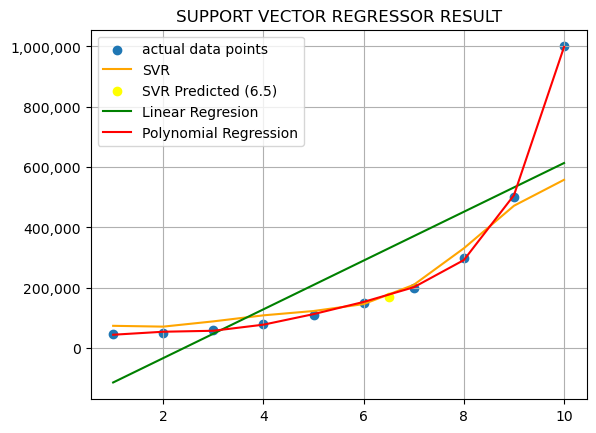

In [552]:
y_pred_scaled = svr_model.predict(X_scaled)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))


plt.scatter(X, y, label="actual data points")
plt.plot(X, y_pred, color='orange', label="SVR")
plt.scatter(6.5, sal_pred_svr, color='yellow', label='SVR Predicted (6.5)')

plt.plot(X, line_reg.predict(X), color='green', label='Linear Regresion')

plt.plot(X, poly_model.predict(X_poly), color='red', label='Polynomial Regression')

# labels
plt.title("SUPPORT VECTOR REGRESSOR RESULT")
plt.legend()
plt.grid(True)



# 🔧 Set Y-axis to plain format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

Salary Predicted by SVR: Rs. 130000.00


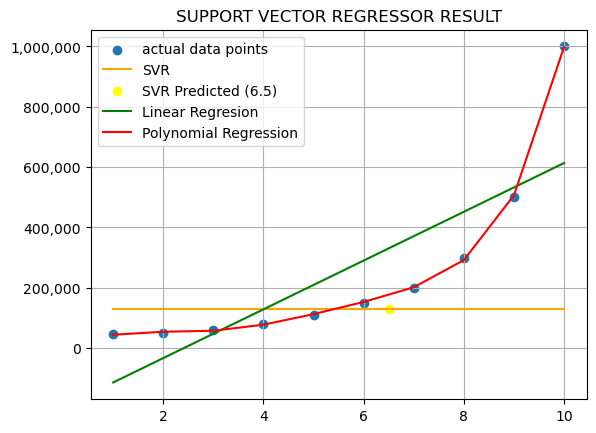

In [568]:
from sklearn.svm import SVR
svr_model = SVR(kernel='poly', degree=6, C=100, gamma=5)
svr_model.fit(X_scaled, y_scaled.ravel()) # fit expects 1D array so ravel it

level_scaled = sc_X.transform([[6.5]])
sal_pred_scaled = svr_model.predict(level_scaled)
sal_pred_svr = sc_y.inverse_transform(sal_pred_scaled.reshape(-1,1))

print(f"Salary Predicted by SVR: Rs. {sal_pred_svr[0][0]:.2f}")

y_pred_scaled = svr_model.predict(X_scaled)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))


plt.scatter(X, y, label="actual data points")
plt.plot(X, y_pred, color='orange', label="SVR")
plt.scatter(6.5, sal_pred_svr, color='yellow', label='SVR Predicted (6.5)')

plt.plot(X, line_reg.predict(X), color='green', label='Linear Regresion')

plt.plot(X, poly_model.predict(X_poly), color='red', label='Polynomial Regression')

# labels
plt.title("SUPPORT VECTOR REGRESSOR RESULT")
plt.legend()
plt.grid(True)



# 🔧 Set Y-axis to plain format
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

In [596]:
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from matplotlib import ticker
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_svr_3d(epsilon, gamma, kernel='rbf', C=1.0, degree=3):
    # Train SVR
    svr_model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, degree=degree)
    svr_model.fit(X_scaled, y_scaled.ravel())

    # Prediction for 6.5
    level_scaled = sc_X.transform([[6.5]])
    sal_pred_scaled = svr_model.predict(level_scaled)
    sal_pred_svr = sc_y.inverse_transform(sal_pred_scaled.reshape(-1, 1))

    # Prediction across grid
    X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)
    X_grid_scaled = sc_X.transform(X_grid)
    y_grid_scaled = svr_model.predict(X_grid_scaled)
    y_grid = sc_y.inverse_transform(y_grid_scaled.reshape(-1, 1))

    # Dummy axis for 3D
    dummy_band = np.linspace(-0.1, 0.1, 10).reshape(-1, 1)
    X_surface, D_surface = np.meshgrid(X_grid.ravel(), dummy_band.ravel())
    Y_surface = np.tile(y_grid.T, (10, 1))  # repeat along dummy_band

    # Plotting
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Actual data points
    dummy_axis = np.zeros_like(X)
    ax.scatter(X.ravel(), dummy_axis.ravel(), y, color='blue', label='Actual Data', s=40)

    # SVR "fat tube"
    ax.plot_surface(X_surface, D_surface, Y_surface, color='orange', alpha=0.8)

    # Highlight predicted point
    ax.scatter(6.5, 0, sal_pred_svr, color='yellow', s=100, label='Predicted at 6.5')

    # Axes labels
    ax.set_xlabel("Position Level")
    ax.set_ylabel("Dummy Axis")
    ax.set_zlabel("Salary")
    ax.set_title(f"Hyper Parameter Tunning\nKernel={kernel}, C={C}, Gamma={gamma}, Epsilon={epsilon}")
    ax.view_init(elev=25, azim=120)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Predicted Salary at Level 6.5")


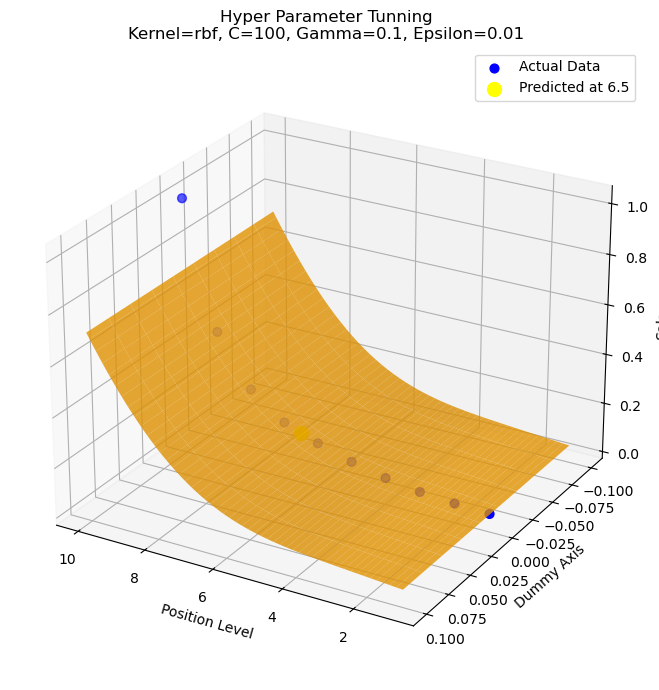

Predicted Salary at Level 6.5


In [598]:
plot_svr_3d(kernel='rbf', C=100, gamma=0.1, epsilon=0.01)


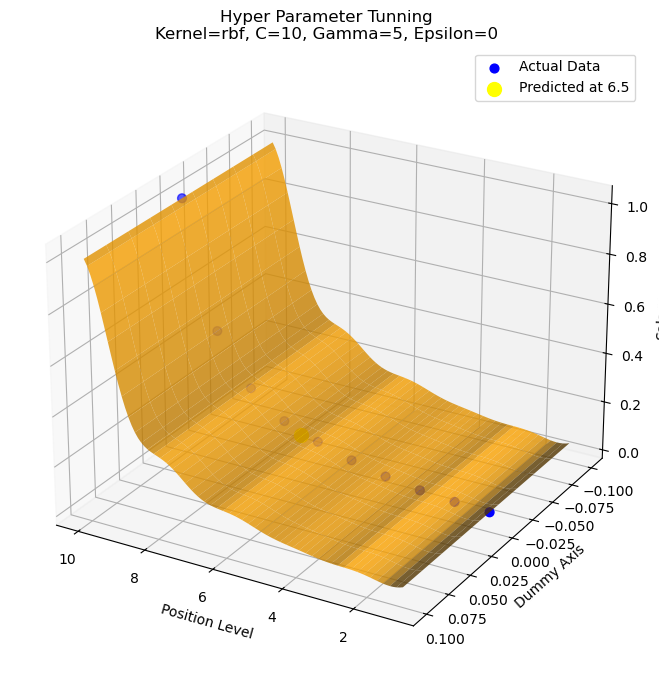

Predicted Salary at Level 6.5


In [618]:
plot_svr_3d(kernel='rbf', C=10, gamma=5, epsilon=0)


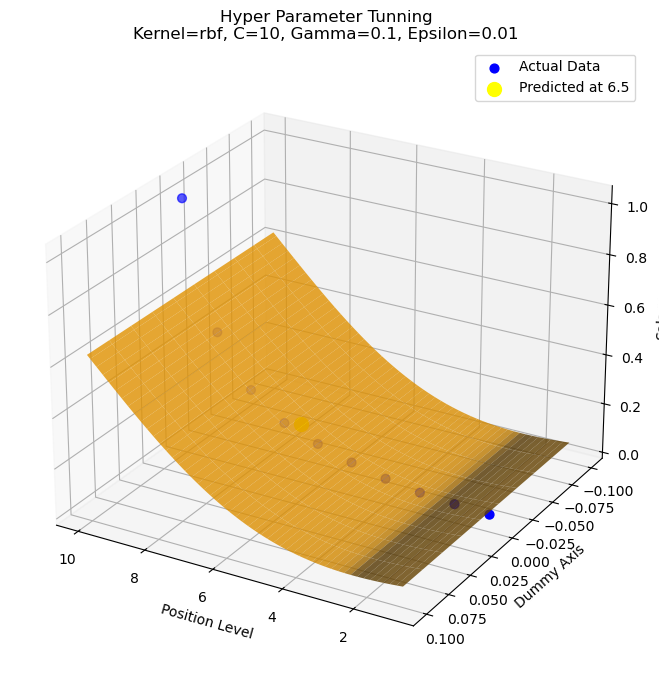

Predicted Salary at Level 6.5


In [606]:
plot_svr_3d(kernel='rbf', C=10, gamma=0.1, epsilon=0.01)


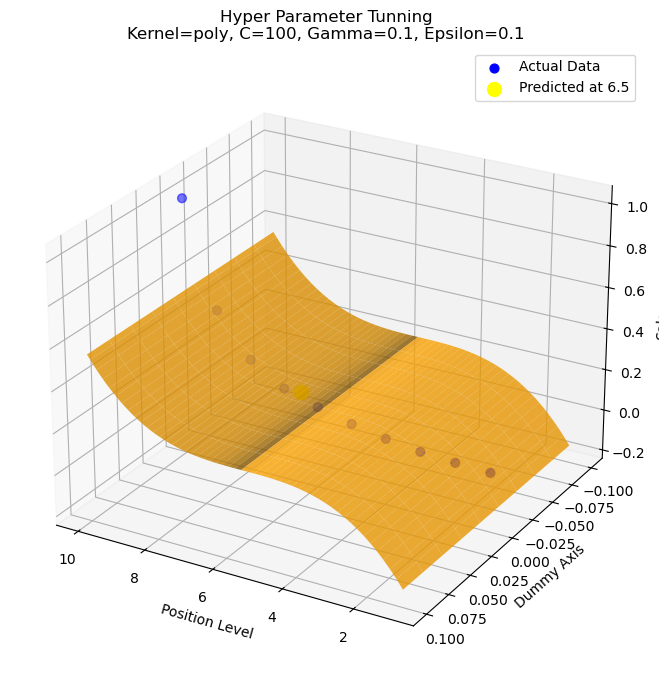

Predicted Salary at Level 6.5


In [622]:
plot_svr_3d(kernel='poly', C=100, gamma=0.1, epsilon=0.1)
